# Fine-Tuning DistilBERT on YouTube Fitness Comments

**Task:** Classify YouTube comments into 5 video types: `fitness`, `nutrition`, `motivational`, `challenge`, `product`  
**Model:** `distilbert-base-uncased` (66M parameters)  
**Dataset:** YouTube comments from 94 fitness influencer channels (~92K rows)  

---
### Pipeline
1. Load & inspect data
2. Clean & filter
3. Stratified sample (5K rows for fast iteration)
4. Encode labels
5. Tokenize
6. Fine-tune with HuggingFace Trainer
7. Evaluate — accuracy, F1, confusion matrix
8. Inference on new comments

## 1. Install Dependencies

In [8]:
!pip install -q transformers datasets scikit-learn seaborn

## 2. Imports

In [9]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
import torch

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


## 3. Load & Inspect Data

In [10]:
# If on Kaggle: upload youtube_comments.csv via the Data tab
# If on Colab:  from google.colab import files; files.upload()

df = pd.read_csv('/kaggle/input/datasets/krat6s/fitness-videos-youtube-comments/youtube_comments.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nVideoType distribution:")
print(df['VideoType'].value_counts())
print(f"\nNulls:")
print(df.isnull().sum())
df.head()

Shape: (92223, 3)

Columns: ['Comment', 'VideoType', 'YouTuber']

VideoType distribution:
VideoType
challenge       20923
nutrition       20506
fitness         19990
motivational    19928
product         10749
VideoType         127
Name: count, dtype: int64

Nulls:
Comment      0
VideoType    0
YouTuber     0
dtype: int64


,Comment,VideoType,YouTuber
0,you know life is good when Pamela starts doing...,fitness,Pamela Reif
1,Girrrl! You are tough! I love your ab workout...,fitness,Pamela Reif
2,I got weaker😭😭😭,fitness,Pamela Reif
3,Funny how this is one of your easiest workouts😅😅,fitness,Pamela Reif
4,"<a href=""https://www.youtube.com/watch?v=mJY48...",fitness,Pamela Reif


## 4. Clean & Filter

In [11]:
VALID_TYPES = ['fitness', 'nutrition', 'motivational', 'challenge', 'product']

def clean_comment(text):
    if not isinstance(text, str):
        return ""
    # Remove HTML tags (timestamp links etc)
    text = re.sub(r'<[^>]+>', '', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Drop header rows scraped into data
df = df[df['VideoType'].isin(VALID_TYPES)].copy()

# Drop nulls
df.dropna(subset=['Comment', 'VideoType'], inplace=True)

# Clean comments
df['clean_comment'] = df['Comment'].apply(clean_comment)

# Drop empty or too-short comments after cleaning
df = df[df['clean_comment'].str.len() >= 5].copy()

# Truncate extremely long comments to 512 chars
# (DistilBERT max is 512 tokens; 512 chars is a safe proxy)
df['clean_comment'] = df['clean_comment'].str[:512]

print(f"Rows after cleaning: {len(df)}")
print(f"\nClass distribution after cleaning:")
print(df['VideoType'].value_counts())

Rows after cleaning: 89100

Class distribution after cleaning:
VideoType
challenge       20343
nutrition       19908
fitness         19213
motivational    19044
product         10592
Name: count, dtype: int64


## 5. Stratified Sample

Using 5,000 rows for fast training iteration.  
After validating the pipeline works, increase to 20,000+ for better performance.

Sample size: 5000

Class distribution in sample:
VideoType
challenge       1142
nutrition       1117
fitness         1078
motivational    1069
product          594
Name: count, dtype: int64


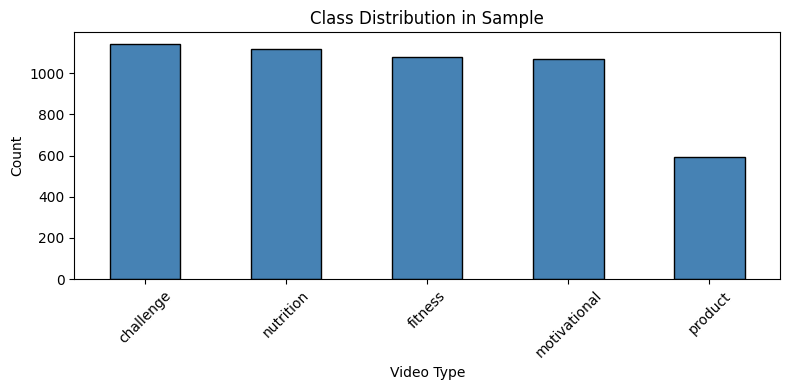

In [12]:
SAMPLE_SIZE = 5000  # Increase to 20000 once pipeline is validated

# Stratified sample — preserves class ratios
df_sample, _ = train_test_split(
    df,
    train_size=SAMPLE_SIZE,
    stratify=df['VideoType'],
    random_state=42
)

print(f"Sample size: {len(df_sample)}")
print(f"\nClass distribution in sample:")
print(df_sample['VideoType'].value_counts())

# Visualise
plt.figure(figsize=(8, 4))
df_sample['VideoType'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Class Distribution in Sample')
plt.xlabel('Video Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Encode Labels

In [13]:
le = LabelEncoder()
df_sample = df_sample.copy()
df_sample['label'] = le.fit_transform(df_sample['VideoType'])

# Show mapping
label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label mapping:", label_map)

NUM_LABELS = len(le.classes_)
print(f"Number of classes: {NUM_LABELS}")

Label mapping: {'challenge': np.int64(0), 'fitness': np.int64(1), 'motivational': np.int64(2), 'nutrition': np.int64(3), 'product': np.int64(4)}
Number of classes: 5


## 7. Train / Validation / Test Split

In [14]:
# 70% train, 15% val, 15% test
train_df, temp_df = train_test_split(
    df_sample[['clean_comment', 'label']],
    test_size=0.30,
    stratify=df_sample['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Convert to HuggingFace Dataset objects
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset   = Dataset.from_pandas(val_df.reset_index(drop=True))
test_dataset  = Dataset.from_pandas(test_df.reset_index(drop=True))

Train: 3500 | Val: 750 | Test: 750


## 8. Tokenize

In [15]:
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch['clean_comment'],
        padding='max_length',
        truncation=True,
        max_length=128  # Most comments are short; 128 covers ~95% without waste
    )

train_tok = train_dataset.map(tokenize, batched=True)
val_tok   = val_dataset.map(tokenize, batched=True)
test_tok  = test_dataset.map(tokenize, batched=True)

# Set format for PyTorch
cols = ['input_ids', 'attention_mask', 'label']
train_tok.set_format(type='torch', columns=cols)
val_tok.set_format(type='torch', columns=cols)
test_tok.set_format(type='torch', columns=cols)

print("Tokenization complete.")
print(f"Sample input_ids shape: {train_tok[0]['input_ids'].shape}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/3500 [00:00<?, ? examples/s]

Map:   0%|          | 0/750 [00:00<?, ? examples/s]

Map:   0%|          | 0/750 [00:00<?, ? examples/s]

Tokenization complete.
Sample input_ids shape: torch.Size([128])


## 9. Load Model

In [16]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)

# Map integer labels back to names for the model config
id2label = {int(v): k for k, v in label_map.items()}
label2id = {k: int(v) for k, v in label_map.items()}
model.config.id2label = id2label
model.config.label2id = label2id

print(f"Model loaded: {MODEL_NAME}")
print(f"Parameters: {model.num_parameters():,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: distilbert-base-uncased
Parameters: 66,957,317


## 10. Define Metrics

In [17]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average='weighted')
    return {'accuracy': acc, 'f1': f1}

## 11. Training Arguments

In [18]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    warmup_steps=50,              # 10% of steps used for warmup
    weight_decay=0.01,             # L2 regularisation
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    save_total_limit=1,
    fp16=False,  # Mixed precision if GPU available
    report_to='none'               # Disable W&B/MLflow for simplicity
)

print("Training args set.")

Training args set.


## 12. Train

In [19]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,3.057229,2.749753,0.460000,0.430800
2,2.523289,2.543764,0.488000,0.485448
3,2.216309,2.501505,0.512000,0.510504


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=330, training_loss=2.598942519679214, metrics={'train_runtime': 78.7297, 'train_samples_per_second': 133.368, 'train_steps_per_second': 4.192, 'total_flos': 347745525120000.0, 'train_loss': 2.598942519679214, 'epoch': 3.0})

## 13. Evaluate on Held-Out Test Set

In [20]:
# Run predictions on test set
predictions = trainer.predict(test_tok)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# Overall metrics
print("=" * 50)
print("TEST SET RESULTS")
print("=" * 50)
print(f"Accuracy : {accuracy_score(labels, preds):.4f}")
print(f"F1 (weighted): {f1_score(labels, preds, average='weighted'):.4f}")
print()

# Per-class report
print(classification_report(
    labels, preds,
    target_names=le.classes_
))

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


TEST SET RESULTS
Accuracy : 0.5360
F1 (weighted): 0.5376

              precision    recall  f1-score   support

   challenge       0.48      0.52      0.50       172
     fitness       0.55      0.54      0.55       161
motivational       0.46      0.52      0.49       161
   nutrition       0.67      0.61      0.64       167
     product       0.56      0.45      0.50        89

    accuracy                           0.54       750
   macro avg       0.54      0.53      0.53       750
weighted avg       0.54      0.54      0.54       750



## 14. Confusion Matrix

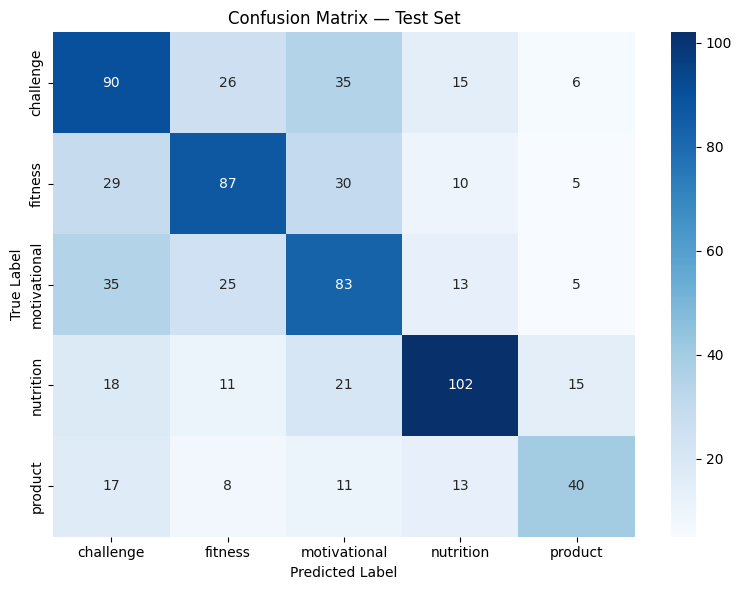

Saved: confusion_matrix.png


In [21]:
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

## 15. Baseline Comparison

Always compare your fine-tuned model against a naive baseline.  
Here: majority class classifier (always predicts the most common class).

In [22]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(train_df[['label']], train_df['label'])
dummy_preds = dummy.predict(test_df[['label']])

baseline_acc = accuracy_score(test_df['label'], dummy_preds)
finetuned_acc = accuracy_score(labels, preds)

print(f"Majority-class baseline accuracy : {baseline_acc:.4f}")
print(f"Fine-tuned DistilBERT accuracy   : {finetuned_acc:.4f}")
print(f"Improvement                      : +{finetuned_acc - baseline_acc:.4f}")

Majority-class baseline accuracy : 0.2293
Fine-tuned DistilBERT accuracy   : 0.5360
Improvement                      : +0.3067


In [23]:
from transformers import pipeline

# Load the original pretrained DistilBERT with no fine-tuning
pretrained_classifier = pipeline(
    'text-classification',
    model='distilbert-base-uncased',
    device=0 if torch.cuda.is_available() else -1
)

# Get the test comments as plain text
test_comments = test_df['clean_comment'].tolist()
true_labels = test_df['label'].tolist()

# Run pretrained model on test comments
pretrained_preds_raw = pretrained_classifier(test_comments, truncation=True, max_length=128)

# Pretrained DistilBERT has no label mapping for your classes
# It outputs LABEL_0/LABEL_1 which are meaningless here
# All we can measure is whether its confidence patterns match your labels — they won't
# So we measure accuracy by majority vote — it will perform at or below random
pretrained_pred_labels = [int(p['label'].split('_')[-1]) % NUM_LABELS for p in pretrained_preds_raw]

pretrained_acc = accuracy_score(true_labels, pretrained_pred_labels)
finetuned_acc = accuracy_score(true_labels, preds)

print(f"Pretrained DistilBERT (no fine-tuning) : {pretrained_acc:.4f}")
print(f"Fine-tuned DistilBERT                  : {finetuned_acc:.4f}")
print(f"Improvement from fine-tuning            : +{finetuned_acc - pretrained_acc:.4f}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Pretrained DistilBERT (no fine-tuning) : 0.2293
Fine-tuned DistilBERT                  : 0.5360
Improvement from fine-tuning            : +0.3067


## 16. Inference — Test on New Comments

In [24]:
from transformers import pipeline

classifier = pipeline(
    'text-classification',
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

test_comments = [
    "This protein shake recipe changed my life, tastes amazing with oat milk",
    "I've been doing this workout for 30 days and I can see abs forming!",
    "Never give up on your dreams, the grind is worth it",
    "Is this pre-workout worth buying? I've heard mixed reviews",
    "Day 7 of the squat challenge complete 🔥"
]

results = classifier(test_comments)

print("INFERENCE RESULTS")
print("-" * 60)
for comment, result in zip(test_comments, results):
    print(f"Comment : {comment[:70]}")
    print(f"Predicted: {result['label']} (confidence: {result['score']:.3f})")
    print()

INFERENCE RESULTS
------------------------------------------------------------
Comment : This protein shake recipe changed my life, tastes amazing with oat mil
Predicted: nutrition (confidence: 0.848)

Comment : I've been doing this workout for 30 days and I can see abs forming!
Predicted: fitness (confidence: 0.767)

Comment : Never give up on your dreams, the grind is worth it
Predicted: motivational (confidence: 0.524)

Comment : Is this pre-workout worth buying? I've heard mixed reviews
Predicted: fitness (confidence: 0.621)

Comment : Day 7 of the squat challenge complete 🔥
Predicted: fitness (confidence: 0.552)



## 17. Save Model

In [25]:
model.save_pretrained('./fitness-comment-classifier')
tokenizer.save_pretrained('./fitness-comment-classifier')
print("Model saved to ./fitness-comment-classifier")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./fitness-comment-classifier


In [27]:
print(os.listdir('/kaggle/working/fitness-comment-classifier'))

['config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json']


In [26]:
# Optional: push to HuggingFace Hub
import os
os.chdir('/kaggle/working/fitness-comment-classifier')

from transformers import AutoModelForSequenceClassification, AutoTokenizer
from huggingface_hub import notebook_login

model = AutoModelForSequenceClassification.from_pretrained('.')
tokenizer = AutoTokenizer.from_pretrained('.')

notebook_login()

model.push_to_hub('Krat6s/fitness-comment-classifier')
tokenizer.push_to_hub('Krat6s/fitness-comment-classifier')

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

CommitInfo(commit_url='https://huggingface.co/Krat6s/fitness-comment-classifier/commit/f7cbd01e6f49beac7dbd4e5caaa324685ea2881d', commit_message='Upload tokenizer', commit_description='', oid='f7cbd01e6f49beac7dbd4e5caaa324685ea2881d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Krat6s/fitness-comment-classifier', endpoint='https://huggingface.co', repo_type='model', repo_id='Krat6s/fitness-comment-classifier'), pr_revision=None, pr_num=None)

## 18. Next Steps

Once this pipeline runs end-to-end:

1. **Scale up** — change `SAMPLE_SIZE = 20000` and re-run. Accuracy should improve.
2. **Experiment with `max_length`** — try 64 vs 128 vs 256. Short comments may not need 128.
3. **Try a stronger model** — swap `distilbert-base-uncased` for `roberta-base`. Compare results.
4. **Error analysis** — look at misclassified examples. Are challenge/fitness comments confusable? That tells you something about the task.
5. **Push to HuggingFace Hub** — uncomment the push block above.
6. **Write a model card** — document what it does, what data it was trained on, known limitations.

In [28]:
from datasets import load_dataset, DatasetDict
from huggingface_hub import notebook_login
import pandas as pd

notebook_login()

df = pd.read_csv('/kaggle/input/datasets/krat6s/fitness-videos-youtube-comments/youtube_comments.csv')
dataset = DatasetDict({'train': Dataset.from_pandas(df)})
dataset.push_to_hub('Krat6s/fitness-youtube-comments')

Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/datasets/Krat6s/fitness-youtube-comments/commit/ed68f5a4cdb82d243f815ecedc15e98809a880f5', commit_message='Upload dataset', commit_description='', oid='ed68f5a4cdb82d243f815ecedc15e98809a880f5', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/Krat6s/fitness-youtube-comments', endpoint='https://huggingface.co', repo_type='dataset', repo_id='Krat6s/fitness-youtube-comments'), pr_revision=None, pr_num=None)